In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import ipywidgets as widgets
from IPython.display import display, clear_output

# === Load CSV ===
df = pd.read_csv("RealLife_2024_7_1_2/First_400_2/ParetoFront_filtered.csv")

# === Define objectives ===
objectives = [
    "Driver Violation", "Commute Distance",
    "Transport Machines", "Transport Attachments",
    "Machines", "Workers", "Attachments"
]

# === Create Widgets ===
x_widget = widgets.Dropdown(options=objectives, value="Machines", description="X:")
y_widget = widgets.Dropdown(options=objectives, value="Commute Distance", description="Y:")
output = widgets.Output()

# === Plot Function ===
def update_plot(*args):
    with output:
        clear_output(wait=True)
        x_col, y_col = x_widget.value, y_widget.value
        sub_df = df[[x_col, y_col]].dropna().sort_values(x_col)

        x, y = sub_df[x_col].values, sub_df[y_col].values
        dx, dy = np.diff(x), np.diff(y)
        tradeoff = np.divide(dy, dx, out=np.zeros_like(dy, dtype=float), where=dx != 0)
        avg_tradeoff = np.mean(np.abs(tradeoff[np.isfinite(tradeoff)]))

        plt.figure(figsize=(8, 5))
        plt.scatter(x, y, alpha=0.8)
        plt.xlabel(x_col)
        plt.ylabel(y_col)
        plt.title(f"{y_col} vs. {x_col}")
        plt.grid(True)
        plt.tight_layout()
        plt.show()
        print(f"🔁 Avg. Trade-off: {avg_tradeoff:.2f} Δ{y_col} / Δ{x_col}")

# === Register change once ===
x_widget.observe(update_plot, names="value")
y_widget.observe(update_plot, names="value")

# === Initial plot + display ===
update_plot()
display(widgets.HBox([x_widget, y_widget]), output)

Output()

Unique pairs: 19
    Workers  Driver Violation
37      114               723
34      114               721
25      115               643
23      115               642
33      116               698
31      116               697
29      116               696
26      116               694
10      118               605
8       118               600
6       118               368
4       118               367
21      118               636
16      118               634
0       118               365
12      118               606
19      118               635
2       118               366
14      118               611
🔁 Avg. Trade-off: -3.6944 → On average, each additional unit of 'Workers' results in a decrease of 3.69 in 'Driver Violation'


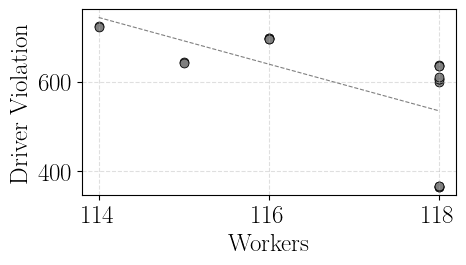

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import rcParams

# === Stil für wissenschaftliches Plotten ===
rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.size": 18,
    "axes.labelsize": 18,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
})

# === Daten laden ===
df = pd.read_csv("RealLife_2024_7_1_2/First_400_2/ParetoFront_filtered.csv")

# === Achsenwahl hier anpassen ===
x_axis = "Workers"  # Beispiel: "Machines", "Workers", etc.
y_axis = "Driver Violation"  # Beispiel: "Driver Violation", "Commute Distance", etc.

list = ["Workers, Driver Violation, Commute Distance, Transport Machines, Transport Attachments, Machines, Attachments"]

# === Plotdaten vorbereiten ===
sub_df = df[[x_axis, y_axis]].dropna().sort_values(x_axis)
x = sub_df[x_axis].values
y = sub_df[y_axis].values

# === Plot erstellen ===
plt.figure(figsize=(5, 3))
plt.scatter(x, y, alpha=0.85, s=40, color="tab:grey", edgecolors="black", linewidth=0.5)

# Achsenbeschriftungen & Stil
plt.xlabel(x_axis)
plt.ylabel(y_axis)
#plt.title(f"{y_axis} vs. {x_axis}", fontsize=16)
plt.grid(True, linestyle="--", alpha=0.4)

# === Trade-off berechnen (nur eindeutige Wertepunkte, sortiert) ===
unique_pairs = sub_df.drop_duplicates(subset=[x_axis, y_axis])
unique_pairs_sorted = unique_pairs.sort_values(by=x_axis)
x_unique = unique_pairs_sorted[x_axis].values
y_unique = unique_pairs_sorted[y_axis].values

dx = np.diff(x_unique)
dy = np.diff(y_unique)
tradeoff = np.divide(dy, dx, out=np.zeros_like(dy, dtype=float), where=dx != 0)
avg_tradeoff_signed = np.mean(tradeoff[np.isfinite(tradeoff)])
direction_text = (
    f"increase of {abs(avg_tradeoff_signed):.2f}"
    if avg_tradeoff_signed > 0
    else f"decrease of {abs(avg_tradeoff_signed):.2f}"
    if avg_tradeoff_signed < 0
    else "no change"
)
print(f"Unique pairs: {len(unique_pairs_sorted)}")
print(unique_pairs_sorted)
print(
    f"🔁 Avg. Trade-off: {avg_tradeoff_signed:.4f} → On average, each additional unit of '{x_axis}' results in a {direction_text} in '{y_axis}'"
)

# === Lineare Trendlinie berechnen und einzeichnen ===
slope, intercept = np.polyfit(x, y, deg=1)
x_fit = np.linspace(x.min(), x.max(), 100)
y_fit = slope * x_fit + intercept
plt.plot(x_fit, y_fit, color="grey", linestyle="--", linewidth=0.8)
#plt.legend(loc="best")
# === Plot speichern ===
plt.tight_layout()
plt.savefig(f"trade_off_plot_{x_axis}_{y_axis}.pdf", bbox_inches="tight")
plt.show()

Unique pairs: 19
    Transport Machines  Commute Distance
21            34760.01         371880.63
18            34771.27         371880.63
17            34840.94         371880.63
15            59538.16         371912.26
12            59593.93         371912.26
10            59786.48         371912.26
8             59792.98         371912.26
0             64794.07         323458.00
5             64814.37         322760.73
3             64829.81         322743.89
6             65175.13         322115.51
33            93098.70         292277.71
31            93098.70         292537.88
29            93098.70         292750.88
26            93098.70         292990.62
25            93110.88         237979.03
23            93110.88         238984.92
36            93110.88         245153.20
34            93110.88         245175.18
🔁 Avg. Trade-off: -253.5870 → On average, each additional unit of 'Transport Machines' results in a decrease of 253.59 in 'Commute Distance'


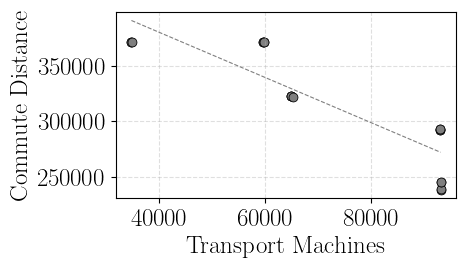

In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import rcParams

# === Stil für wissenschaftliches Plotten ===
rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.size": 18,
    "axes.labelsize": 18,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
})

# === Daten laden ===
df = pd.read_csv("RealLife_2024_7_1_2/First_400_2/ParetoFront_filtered.csv")

# === Achsenwahl hier anpassen ===
y_axis = "Commute Distance"  # Beispiel: "Machines", "Workers", etc.
x_axis = "Transport Machines"  # Beispiel: "Driver Violation", "Commute Distance", etc.

list = ["Workers, Driver Violation, Commute Distance, Transport Machines, Transport Attachments, Machines, Attachments"]

# === Plotdaten vorbereiten ===
sub_df = df[[x_axis, y_axis]].dropna().sort_values(x_axis)
x = sub_df[x_axis].values
y = sub_df[y_axis].values

# === Plot erstellen ===
plt.figure(figsize=(5, 3))
plt.scatter(x, y, alpha=0.85, s=40, color="tab:grey", edgecolors="black", linewidth=0.5)

# Achsenbeschriftungen & Stil
plt.xlabel(x_axis)
plt.ylabel(y_axis)
#plt.title(f"{y_axis} vs. {x_axis}", fontsize=16)
plt.grid(True, linestyle="--", alpha=0.4)

# === Trade-off berechnen (nur eindeutige Wertepunkte, sortiert) ===
unique_pairs = sub_df.drop_duplicates(subset=[x_axis, y_axis])
unique_pairs_sorted = unique_pairs.sort_values(by=x_axis)
x_unique = unique_pairs_sorted[x_axis].values
y_unique = unique_pairs_sorted[y_axis].values

dx = np.diff(x_unique)
dy = np.diff(y_unique)
tradeoff = np.divide(dy, dx, out=np.zeros_like(dy, dtype=float), where=dx != 0)
avg_tradeoff_signed = np.mean(tradeoff[np.isfinite(tradeoff)])
direction_text = (
    f"increase of {abs(avg_tradeoff_signed):.2f}"
    if avg_tradeoff_signed > 0
    else f"decrease of {abs(avg_tradeoff_signed):.2f}"
    if avg_tradeoff_signed < 0
    else "no change"
)
print(f"Unique pairs: {len(unique_pairs_sorted)}")
print(unique_pairs_sorted)
print(
    f"🔁 Avg. Trade-off: {avg_tradeoff_signed:.4f} → On average, each additional unit of '{x_axis}' results in a {direction_text} in '{y_axis}'"
)
slope, intercept = np.polyfit(x, y, deg=1)
x_fit = np.linspace(x.min(), x.max(), 100)
y_fit = slope * x_fit + intercept
plt.plot(x_fit, y_fit, color="grey", linestyle="--", linewidth=0.8)
# === Plot speichern ===
plt.tight_layout()
plt.savefig(f"trade_off_plot_{x_axis}_{y_axis}.pdf", bbox_inches="tight")
plt.show()

Unique pairs: 14
    Workers  Commute Distance
37      114         245153.20
34      114         245175.18
25      115         237979.03
23      115         238984.92
33      116         292277.71
31      116         292537.88
29      116         292750.88
26      116         292990.62
19      118         371880.63
0       118         323458.00
2       118         322743.89
4       118         322760.73
6       118         322115.51
8       118         371912.26
🔁 Avg. Trade-off: 6580.1265 → On average, each additional unit of 'Workers' results in a increase of 6580.13 in 'Commute Distance'


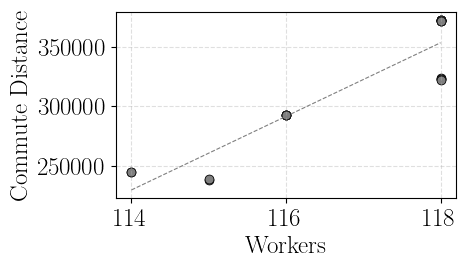

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import rcParams

# === Stil für wissenschaftliches Plotten ===
rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.size": 18,
    "axes.labelsize": 18,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
})

# === Daten laden ===
df = pd.read_csv("RealLife_2024_7_1_2/First_400_2/ParetoFront_filtered.csv")

# === Achsenwahl hier anpassen ===
y_axis = "Commute Distance"  # Beispiel: "Machines", "Workers", etc.
x_axis = "Workers"  # Beispiel: "Driver Violation", "Commute Distance", etc.

list = ["Workers, Driver Violation, Commute Distance, Transport Machines, Transport Attachments, Machines, Attachments"]

# === Plotdaten vorbereiten ===
sub_df = df[[x_axis, y_axis]].dropna().sort_values(x_axis)
x = sub_df[x_axis].values
y = sub_df[y_axis].values

# === Plot erstellen ===
plt.figure(figsize=(5, 3))
plt.scatter(x, y, alpha=0.85, s=40, color="tab:grey", edgecolors="black", linewidth=0.5)

# Achsenbeschriftungen & Stil
plt.xlabel(x_axis)
plt.ylabel(y_axis)
#plt.title(f"{y_axis} vs. {x_axis}", fontsize=16)
plt.grid(True, linestyle="--", alpha=0.4)

# === Trade-off berechnen (nur eindeutige Wertepunkte, sortiert) ===
unique_pairs = sub_df.drop_duplicates(subset=[x_axis, y_axis])
unique_pairs_sorted = unique_pairs.sort_values(by=x_axis)
x_unique = unique_pairs_sorted[x_axis].values
y_unique = unique_pairs_sorted[y_axis].values

dx = np.diff(x_unique)
dy = np.diff(y_unique)
tradeoff = np.divide(dy, dx, out=np.zeros_like(dy, dtype=float), where=dx != 0)
avg_tradeoff_signed = np.mean(tradeoff[np.isfinite(tradeoff)])
direction_text = (
    f"increase of {abs(avg_tradeoff_signed):.2f}"
    if avg_tradeoff_signed > 0
    else f"decrease of {abs(avg_tradeoff_signed):.2f}"
    if avg_tradeoff_signed < 0
    else "no change"
)
print(f"Unique pairs: {len(unique_pairs_sorted)}")
print(unique_pairs_sorted)
print(
    f"🔁 Avg. Trade-off: {avg_tradeoff_signed:.4f} → On average, each additional unit of '{x_axis}' results in a {direction_text} in '{y_axis}'"
)
slope, intercept = np.polyfit(x, y, deg=1)
x_fit = np.linspace(x.min(), x.max(), 100)
y_fit = slope * x_fit + intercept
plt.plot(x_fit, y_fit, color="grey", linestyle="--", linewidth=0.8)
# === Plot speichern ===
plt.tight_layout()
plt.savefig(f"trade_off_plot_{x_axis}_{y_axis}.pdf", bbox_inches="tight")
plt.show()

Unique pairs: 14
    Workers  Transport Machines
37      114            93110.88
25      115            93110.88
33      116            93098.70
19      118            34771.27
21      118            34760.01
0       118            64794.07
16      118            34840.94
2       118            64829.81
4       118            64814.37
6       118            65175.13
8       118            59792.98
10      118            59786.48
12      118            59593.93
14      118            59538.16
🔁 Avg. Trade-off: -2244.2996 → On average, each additional unit of 'Workers' results in a decrease of 2244.30 in 'Transport Machines'


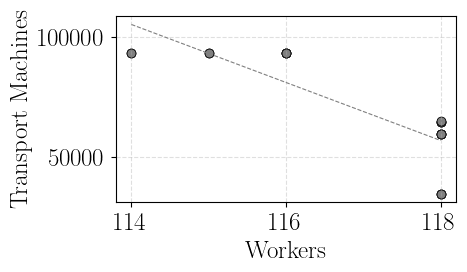

In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import rcParams

# === Stil für wissenschaftliches Plotten ===
rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.size": 18,
    "axes.labelsize": 18,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
})

# === Daten laden ===
df = pd.read_csv("RealLife_2024_7_1_2/First_400_2/ParetoFront_filtered.csv")

# === Achsenwahl hier anpassen ===
y_axis = "Transport Machines"  # Beispiel: "Machines", "Workers", etc.
x_axis = "Workers"  # Beispiel: "Driver Violation", "Commute Distance", etc.

list = ["Workers, Driver Violation, Commute Distance, Transport Machines, Transport Attachments, Machines, Attachments"]

# === Plotdaten vorbereiten ===
sub_df = df[[x_axis, y_axis]].dropna().sort_values(x_axis)
x = sub_df[x_axis].values
y = sub_df[y_axis].values

# === Plot erstellen ===
plt.figure(figsize=(5, 3))
plt.scatter(x, y, alpha=0.85, s=40, color="tab:grey", edgecolors="black", linewidth=0.5)

# Achsenbeschriftungen & Stil
plt.xlabel(x_axis)
plt.ylabel(y_axis)
#plt.title(f"{y_axis} vs. {x_axis}", fontsize=16)
plt.grid(True, linestyle="--", alpha=0.4)

# === Trade-off berechnen (nur eindeutige Wertepunkte, sortiert) ===
unique_pairs = sub_df.drop_duplicates(subset=[x_axis, y_axis])
unique_pairs_sorted = unique_pairs.sort_values(by=x_axis)
x_unique = unique_pairs_sorted[x_axis].values
y_unique = unique_pairs_sorted[y_axis].values

dx = np.diff(x_unique)
dy = np.diff(y_unique)
tradeoff = np.divide(dy, dx, out=np.zeros_like(dy, dtype=float), where=dx != 0)
avg_tradeoff_signed = np.mean(tradeoff[np.isfinite(tradeoff)])
direction_text = (
    f"increase of {abs(avg_tradeoff_signed):.2f}"
    if avg_tradeoff_signed > 0
    else f"decrease of {abs(avg_tradeoff_signed):.2f}"
    if avg_tradeoff_signed < 0
    else "no change"
)
print(f"Unique pairs: {len(unique_pairs_sorted)}")
print(unique_pairs_sorted)
print(
    f"🔁 Avg. Trade-off: {avg_tradeoff_signed:.4f} → On average, each additional unit of '{x_axis}' results in a {direction_text} in '{y_axis}'"
)
slope, intercept = np.polyfit(x, y, deg=1)
x_fit = np.linspace(x.min(), x.max(), 100)
y_fit = slope * x_fit + intercept
plt.plot(x_fit, y_fit, color="grey", linestyle="--", linewidth=0.8)
# === Plot speichern ===
plt.tight_layout()
plt.savefig(f"trade_off_plot_{x_axis}_{y_axis}.pdf", bbox_inches="tight")
plt.show()

<AxesSubplot:>

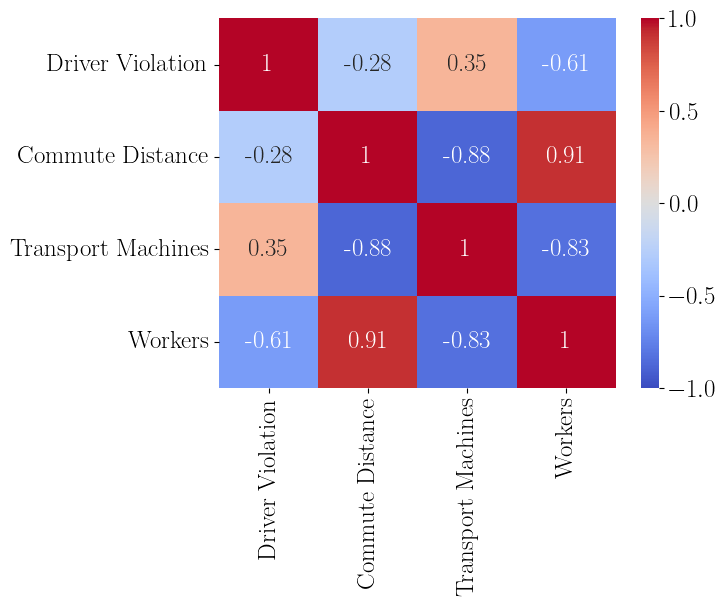

In [16]:
import seaborn as sns

# Ziele ohne "Attachments", "Transport Attachments" und "Machines"
objectives_corr = [obj for obj in objectives if obj not in ["Attachments", "Transport Attachments", "Machines"]]


sns.heatmap(df[objectives_corr].corr(), annot=True, cmap="coolwarm", vmin=-1, vmax=1)

In [17]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import rcParams

# === Stil für wissenschaftliches Plotten ===
rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.size": 16,
    "axes.labelsize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
})

# === Daten einlesen ===
df = pd.read_csv("RealLife_2024_7_1_2/First_400_2/ParetoFront_filtered.csv")

# === Spaltenauswahl und neue Labels ===
rename_dict = {
    "Driver Violation": r"$F_2$",
    "Commute Distance": r"$F_3$",
    "Transport Machines": r"$F_4$",
    "Workers": r"$F_7$"
}
selected_columns = list(rename_dict.keys())

# === Korrelationsmatrix berechnen ===
corr = df[selected_columns].corr()
corr.rename(index=rename_dict, columns=rename_dict, inplace=True)

# === Nur untere Dreiecksmatrix anzeigen (ohne Diagonale) ===
mask = np.triu(np.ones_like(corr, dtype=bool), k=0)

# === Plot erstellen ===
plt.figure(figsize=(7, 6))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="vlag",
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
    annot_kws={"fontsize": 13},
)

# === Achsentitel und Layout ===
plt.xticks(rotation=0, ha="right")
plt.yticks(rotation=0)
plt.title(r"\textbf{Correlation Matrix of Selected Objectives}", pad=20)
plt.tight_layout()

# === Speichern als PDF ===
#plt.savefig("correlation_heatmap_selected_clean.pdf", bbox_inches="tight")
plt.show()

TypeError: 'list' object is not callable

In [ ]:
from scipy.stats import pearsonr

x = df["Workers"]
y = df["Transport Machines"]

r_value, p_value = pearsonr(x, y)
print(f"r = {r_value:.4f}, p = {p_value:.4e}")

r = -0.8313, p = 1.0282e-10


<AxesSubplot:>

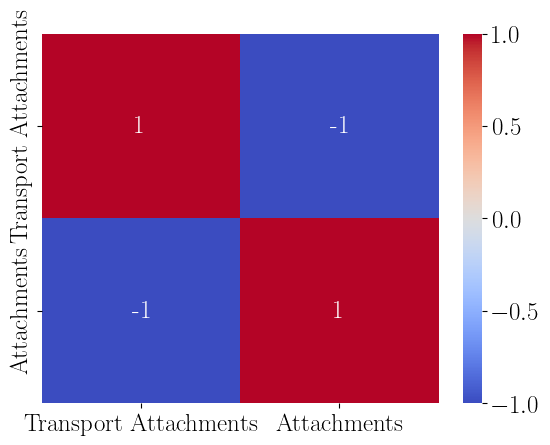

In [ ]:
import seaborn as sns

# Ziele ohne "Attachments", "Transport Attachments" und "Machines"
objectives_corr = [obj for obj in objectives if obj not in ["Workers", "Transport Machines", "Machines", "Driver Violation", "Commute Distance"]]

sns.heatmap(df[objectives_corr].corr(), annot=True, cmap="coolwarm", vmin=-1, vmax=1)

In [ ]:
from scipy.stats import pearsonr

x = df["Attachments"]
y = df["Transport Attachments"]

r_value, p_value = pearsonr(x, y)
print(f"r = {r_value:.4f}, p = {p_value:.4e}")

r = -1.0000, p = 0.0000e+00


In [46]:
import pandas as pd

# === Daten einlesen ===
df = pd.read_csv("RealLife_2024_7_1_2/First_400_2/ParetoFront_filtered.csv")

# === Nur relevante Spalten extrahieren ===
sub_df = df[["Workers", "Transport Machines", "Driver Violation"]].dropna()

# === Duplikate entfernen und Mittelwert für Driver Violation pro Paar berechnen ===
unique_avg = sub_df.groupby(["Workers", "Transport Machines"], as_index=False)["Driver Violation"].mean()

# === Sortiert anzeigen ===
print(f"🔁 Unique Pairs: {len(unique_avg)}")
print(unique_avg.sort_values(["Workers", "Transport Machines"]).head(10))  # z.B. nur die ersten 10 Zeilen

🔁 Unique Pairs: 14
   Workers  Transport Machines  Driver Violation
0      114            93110.88            722.00
1      115            93110.88            642.50
2      116            93098.70            696.25
3      118            34760.01            636.00
4      118            34771.27            635.00
5      118            34840.94            634.00
6      118            59538.16            611.00
7      118            59593.93            606.00
8      118            59786.48            605.00
9      118            59792.98            600.00


🔁 Unique Pairs: 11
    Driver Violation  Transport Machines
0                365            64794.07
2                366            64829.81
4                367            64814.37
6                368            65175.13
8                600            59792.98
10               605            59786.48
12               606            59593.93
14               611            59538.16
16               634            34840.94
18               635            34771.27
20               636            34760.01
🔁 Avg. Trade-off: -100.19 → On average, each additional unit of Driver Violation results in a change of -100.19 km in Transport Machines


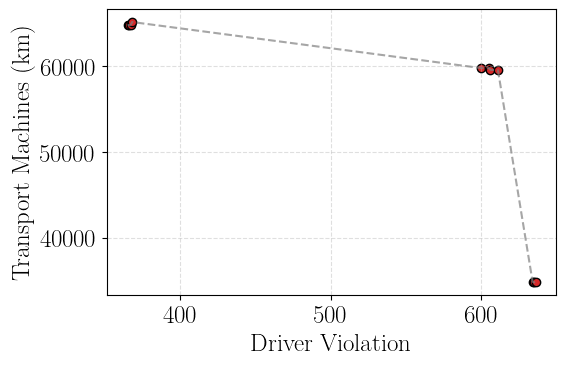

In [51]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# === Daten einlesen ===
df = pd.read_csv("RealLife_2024_7_1_2/First_400_2/ParetoFront_filtered.csv")

# === Nur Zeilen mit 118 Arbeitern auswählen ===
df_118 = df[df["Workers"] == 118].copy()

# === Doppelte Kombinationen (Driver Violation & Transport Machines) entfernen ===
df_unique = df_118.drop_duplicates(subset=["Driver Violation", "Transport Machines"])
df_unique = df_unique.sort_values("Driver Violation")

# === Trade-off berechnen (umgekehrt) ===
x = df_unique["Driver Violation"].values
y = df_unique["Transport Machines"].values
dx = np.diff(x)
dy = np.diff(y)
tradeoff = np.divide(dy, dx, out=np.zeros_like(dy, dtype=float), where=dx != 0)
avg_tradeoff = np.mean(tradeoff[np.isfinite(tradeoff)])

# === Ergebnis ausgeben ===
print(f"🔁 Unique Pairs: {len(df_unique)}")
print(df_unique[["Driver Violation", "Transport Machines"]])
print(f"🔁 Avg. Trade-off: {avg_tradeoff:.2f} → On average, each additional unit of Driver Violation results in a change of {avg_tradeoff:.2f} km in Transport Machines")

# === Plot erstellen ===
plt.figure(figsize=(6, 4))
plt.scatter(x, y, color="tab:red", edgecolor="black")
plt.plot(x, y, linestyle="--", color="grey", alpha=0.7)
plt.xlabel("Driver Violation")
plt.ylabel("Transport Machines (km)")
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

# === Daten einlesen ===
df = pd.read_csv("RealLife_2024_7_1_2/First_400_2/ParetoFront_filtered.csv")

# === Nur relevante Spalten extrahieren ===
sub_df = df[["Workers", "Transport Machines", "Driver Violation"]].dropna()

# === Duplikate entfernen und Mittelwert für Driver Violation pro Paar berechnen ===
unique_avg = sub_df.groupby(["Workers", "Transport Machines"], as_index=False)["Driver Violation"].mean()

# === Sortiert anzeigen ===
print(f"🔁 Unique Pairs: {len(unique_avg)}")
print(unique_avg.sort_values(["Workers", "Transport Machines"]).head(10))  # z.B. nur die ersten 10 Zeilen

🔁 Unique Pairs: 14
   Workers  Transport Machines  Driver Violation
0      114            93110.88            722.00
1      115            93110.88            642.50
2      116            93098.70            696.25
3      118            34760.01            636.00
4      118            34771.27            635.00
5      118            34840.94            634.00
6      118            59538.16            611.00
7      118            59593.93            606.00
8      118            59786.48            605.00
9      118            59792.98            600.00


In [58]:
import pandas as pd

# === Daten einlesen ===
df = pd.read_csv("RealLife_2024_7_1_2/First_400_2/ParetoFront_filtered.csv")

# === Nur relevante Spalten extrahieren ===
sub_df = df[["Commute Distance", "Transport Machines", "Driver Violation"]].dropna()

# === Duplikate entfernen und Mittelwert für Driver Violation pro Paar berechnen ===
unique_avg = sub_df.groupby(["Commute Distance", "Transport Machines"], as_index=False)["Driver Violation"].mean()

# === Sortiert anzeigen ===
print(f"🔁 Unique Pairs: {len(unique_avg)}")
print(unique_avg.sort_values(["Commute Distance", "Transport Machines"]).head(10))  # z.B. nur die ersten 10 Zeilen

🔁 Unique Pairs: 19
   Commute Distance  Transport Machines  Driver Violation
0         237979.03            93110.88             643.0
1         238984.92            93110.88             642.0
2         245153.20            93110.88             723.0
3         245175.18            93110.88             721.0
4         292277.71            93098.70             698.0
5         292537.88            93098.70             697.0
6         292750.88            93098.70             696.0
7         292990.62            93098.70             694.0
8         322115.51            65175.13             368.0
9         322743.89            64829.81             366.0
